In [ ]:
import pickle
import numpy as np
import librosa
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import train_test_split

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [27]:
def extract_feature(data, sr, mfcc, chroma, mel):
    if chroma:                          
        stft = np.abs(librosa.stft(data))  
    result = np.array([])
    if mfcc:                          
        mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)
        result = np.hstack((result, mfccs))
    if chroma:                          
        chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T,axis=0)
        result = np.hstack((result, chroma))
        
    if mel:           
        mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T,axis=0)
        result = np.hstack((result, mel))
        
    return result 

In [28]:
with open("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Data/data_processing/Audio/subject_01_aud.pkl", "rb") as f:
    data_aud = pickle.load(f)

with open("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Data/data_processing/EEG/subject_01_eeg.pkl", "rb") as f:
    data_eeg = pickle.load(f)


In [29]:
# Unpack data into training and testing features and labels
X_train_aud, y_train_aud, X_test_aud, y_test_aud = data_aud
X_train_eeg, y_train_eeg, X_test_eeg, y_test_eeg = data_eeg

In [30]:
X_train_aud = np.array([extract_feature(s, sr=16000, mfcc=True, chroma=True, mel=True) for s in X_train_aud])
X_test_aud = np.array([extract_feature(s, sr=16000, mfcc=True, chroma=True, mel=True) for s in X_test_aud])

In [31]:
X_train_aud = torch.tensor(X_train_aud).unsqueeze(1).float()
y_train_aud = torch.tensor(y_train_aud)
X_test_aud = torch.tensor(X_test_aud).unsqueeze(1).float()
y_test_aud = torch.tensor(y_test_aud)

In [32]:
X_train_eeg = torch.tensor(X_train_eeg).unsqueeze(1).float()
X_test_eeg = torch.tensor(X_test_eeg).unsqueeze(1).float()

In [33]:
emotions = ["Neutral", "Sadness", "Anger", "Happiness", "Calmness"]

## Define Data Loader

In [34]:
class PairedModalDataset(Dataset):
    def __init__(self, X_eeg, X_audio, y):
        assert len(X_eeg) == len(X_audio) == len(y)
        self.X_eeg = torch.tensor(X_eeg, dtype=torch.float32)
        self.X_audio = torch.tensor(X_audio, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_eeg[idx], self.X_audio[idx], self.y[idx]

In [35]:
batch_size = 32
# Create a validation split from the training set
idx = np.arange(len(y_train_aud))
train_split_idx, val_split_idx = train_test_split(
    idx,
    test_size=0.1,
    random_state=42,
    stratify=np.array(y_train_aud)
)

# Keep originals, then slice
X_train_eeg_all = X_train_eeg
X_train_aud_all = X_train_aud
y_train_all = np.array(y_train_aud)

X_train_eeg = X_train_eeg_all[train_split_idx]
X_train_audio = X_train_aud_all[train_split_idx]
y_train = y_train_all[train_split_idx]

X_val_eeg = X_train_eeg_all[val_split_idx]
X_val_audio = X_train_aud_all[val_split_idx]
y_val = y_train_all[val_split_idx]

train_ds = PairedModalDataset(X_train_eeg, X_train_audio, y_train)  # audio and eeg Y are the same
val_ds = PairedModalDataset(X_val_eeg, X_val_audio, y_val)
test_ds  = PairedModalDataset(X_test_eeg,  X_test_aud,  y_test_aud)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)


/tmp/ipykernel_2493694/2166164010.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  stratify=np.array(y_train_aud)
/tmp/ipykernel_2493694/2166164010.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_train_all = np.array(y_train_aud)
/tmp/ipykernel_2493694/1108307568.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  

## Models

EEGNet + AudioSCNN backbones feed CoGCN (one view per modality).


In [69]:
from models import EEGNet, AudioSCNN, CoGCN
from util import construct_graph, sparse_mx_to_torch_sparse_tensor

n_class = len(emotions)

eeg_backbone = EEGNet(
    nb_classes=n_class,
    Chans=30,
    Samples=500,
    dropoutRate=0.5,
    kernLength=300,
    F1=8,
    D=8,
    F2=64,
    norm_rate=0.25,
    dropoutType='Dropout',
).to(device)
aud_backbone = AudioSCNN(n_classes=n_class).to(device)


In [127]:
eeg_backbone.load_state_dict(torch.load("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/eeg_cnn.pth", map_location=device))
aud_backbone.load_state_dict(torch.load("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/audio_scnn.pth", map_location=device))

<All keys matched successfully>

## Train (Backbones + CoGCN)

We build graphs from current backbone features (detached) and train end-to-end.


### Build indices & graphs (frozen phase)


In [128]:
# Build full tensors and indices (train/val/test are contiguous blocks)
X_eeg_all = torch.cat([X_train_eeg, X_val_eeg, X_test_eeg], dim=0).to(device)
X_aud_all = torch.cat([X_train_audio, X_val_audio, X_test_aud], dim=0).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
y_val_t = torch.tensor(y_val, dtype=torch.long, device=device)
y_test_t = y_test_aud.to(device).long() if torch.is_tensor(y_test_aud) else torch.tensor(y_test_aud, dtype=torch.long, device=device)
y_all = torch.cat([y_train_t, y_val_t, y_test_t], dim=0)

n_train = len(y_train)
n_val = len(y_val)
n_test = len(y_test_aud)
train_idx = torch.arange(0, n_train, device=device)
val_idx = torch.arange(n_train, n_train + n_val, device=device)
test_idx = torch.arange(n_train + n_val, n_train + n_val + n_test, device=device)

# Hyperparams
lr = 1e-3
weight_decay = 5e-4
k = 10
epochs_frozen = 500

low_lr = 1e-4
epochs_finetune = 100
rebuild_epochs = {1, max(2, epochs_finetune // 2)}  # rebuild once or twice

# CoGCN params
lr_alpha = 1
dropout = 0.3


### Freeze backbones and build graphs once


In [129]:
def build_graphs(feat_eeg, feat_aud, y_np, k):
    Adj0 = construct_graph(feat_eeg, targets=y_np, k=k, metric="euclidean")
    Adj1 = construct_graph(feat_aud, targets=y_np, k=k, metric="euclidean")
    return [
        sparse_mx_to_torch_sparse_tensor(Adj0).to(device),
        sparse_mx_to_torch_sparse_tensor(Adj1).to(device),
    ]

def set_requires_grad(model, flag):
    for p in model.parameters():
        p.requires_grad = flag

# Freeze backbones
set_requires_grad(eeg_backbone, False)
set_requires_grad(aud_backbone, False)
eeg_backbone.eval()
aud_backbone.eval()

with torch.no_grad():
    logits_eeg, feat_eeg = eeg_backbone(X_eeg_all, return_features=True)
    logits_aud, feat_aud = aud_backbone(X_aud_all, return_features=True)

feat_eeg = feat_eeg.detach().cpu().numpy().astype(np.float32)
feat_aud = feat_aud.detach().cpu().numpy().astype(np.float32)

adjs = build_graphs(feat_eeg, feat_aud, y_all.detach().cpu().numpy(), k)


### Init CoGCN per view + optimizers


In [130]:
n_view = 2
cogcn_nets = [
    CoGCN(nfeat=feat_eeg.shape[1], nclass=n_class, adjs=adjs, n_view=n_view, lr_alpha=lr_alpha, dropout=dropout, device=device).to(device),
    CoGCN(nfeat=feat_aud.shape[1], nclass=n_class, adjs=adjs, n_view=n_view, lr_alpha=lr_alpha, dropout=dropout, device=device).to(device),
]

optimizers = [
    torch.optim.Adam(cogcn_nets[0].parameters(), lr=lr, weight_decay=weight_decay),
    torch.optim.Adam(cogcn_nets[1].parameters(), lr=lr, weight_decay=weight_decay),
]


### Frozen phase training (per-view loss)


In [131]:
best_val = 0.0
best_epoch = 0
best_state = None

# Cache feature tensors once (backbones are frozen)
feat_eeg_t = torch.tensor(feat_eeg, device=device)
feat_aud_t = torch.tensor(feat_aud, device=device)

for epoch in range(1, epochs_frozen + 1):
    # train each view separately
    for v in range(n_view):
        cogcn_nets[v].train()
        optimizers[v].zero_grad()
        out_v = cogcn_nets[v](feat_eeg_t if v == 0 else feat_aud_t)
        loss = F.nll_loss(out_v[train_idx], y_all[train_idx])
        loss.backward()
        optimizers[v].step()
        cogcn_nets[v].gc1.update_alpha()
        cogcn_nets[v].gc2.update_alpha()

    # ensemble eval (train/val only)
    for v in range(n_view):
        cogcn_nets[v].eval()
    with torch.no_grad():
        out_sum = cogcn_nets[0](feat_eeg_t) + cogcn_nets[1](feat_aud_t)

    pred = out_sum.argmax(dim=1)
    train_acc = (pred[train_idx] == y_all[train_idx]).float().mean().item()
    val_acc = (pred[val_idx] == y_all[val_idx]).float().mean().item()

    if val_acc > best_val:
        best_val = val_acc
        best_epoch = epoch
        best_state = {
            'cogcn0': copy.deepcopy(cogcn_nets[0].state_dict()),
            'cogcn1': copy.deepcopy(cogcn_nets[1].state_dict()),
        }

    if epoch % 20 == 0 or epoch == 1:
        print(f"[Frozen] Epoch {epoch:03d} | acc train/val: {train_acc:.3f}/{val_acc:.3f}")

print('Best val:', best_val, 'Best epoch:', best_epoch)

# Load best checkpoint from memory
if best_state is not None:
    cogcn_nets[0].load_state_dict(best_state['cogcn0'])
    cogcn_nets[1].load_state_dict(best_state['cogcn1'])


[Frozen] Epoch 001 | acc train/val: 0.381/0.500
[Frozen] Epoch 020 | acc train/val: 0.984/0.929
[Frozen] Epoch 040 | acc train/val: 0.992/0.893
[Frozen] Epoch 060 | acc train/val: 1.000/0.893
[Frozen] Epoch 080 | acc train/val: 1.000/0.893
[Frozen] Epoch 100 | acc train/val: 1.000/0.893
[Frozen] Epoch 120 | acc train/val: 1.000/0.893
[Frozen] Epoch 140 | acc train/val: 1.000/0.893
[Frozen] Epoch 160 | acc train/val: 1.000/0.893
[Frozen] Epoch 180 | acc train/val: 1.000/0.893
[Frozen] Epoch 200 | acc train/val: 1.000/0.893
[Frozen] Epoch 220 | acc train/val: 1.000/0.893
[Frozen] Epoch 240 | acc train/val: 1.000/0.893
[Frozen] Epoch 260 | acc train/val: 1.000/0.893
[Frozen] Epoch 280 | acc train/val: 1.000/0.893
[Frozen] Epoch 300 | acc train/val: 1.000/0.893
[Frozen] Epoch 320 | acc train/val: 1.000/0.893
[Frozen] Epoch 340 | acc train/val: 1.000/0.893
[Frozen] Epoch 360 | acc train/val: 1.000/0.893
[Frozen] Epoch 380 | acc train/val: 1.000/0.893
[Frozen] Epoch 400 | acc train/val: 1.00

### Fine-tune (unfreeze backbones, low LR)


In [133]:
# Unfreeze backbones
set_requires_grad(eeg_backbone, True)
set_requires_grad(aud_backbone, True)

# Single optimizer over all params (backbones + CoGCN nets)
params = list(eeg_backbone.parameters()) + list(aud_backbone.parameters())
for net in cogcn_nets:
    params += list(net.parameters())
opt = torch.optim.Adam(params, lr=low_lr, weight_decay=weight_decay)

best_val = 0.0
best_epoch = 0
best_state = None
best_adjs = None

for epoch in range(1, epochs_finetune + 1):
    eeg_backbone.train()
    aud_backbone.train()
    for net in cogcn_nets:
        net.train()

    _, feat_eeg_t = eeg_backbone(X_eeg_all, return_features=True)
    _, feat_aud_t = aud_backbone(X_aud_all, return_features=True)

    # Rebuild graphs once or twice using updated features
    if epoch % 10 == 0:
        adjs = build_graphs(
            feat_eeg_t.detach().cpu().numpy().astype(np.float32),
            feat_aud_t.detach().cpu().numpy().astype(np.float32),
            y_all.detach().cpu().numpy(),
            k,
        )
        for net in cogcn_nets:
            net.gc1.adjs = adjs
            net.gc2.adjs = adjs
            net.gc1._update_adj()
            net.gc2._update_adj()

    # Per-view losses, summed (graphs fixed between rebuilds)
    out_v0 = cogcn_nets[0](feat_eeg_t)
    out_v1 = cogcn_nets[1](feat_aud_t)
    loss = F.nll_loss(out_v0[train_idx], y_all[train_idx]) + \
            F.nll_loss(out_v1[train_idx], y_all[train_idx])

    opt.zero_grad()
    loss.backward()
    opt.step()

    for net in cogcn_nets:
        net.gc1.update_alpha()
        net.gc2.update_alpha()

    # Ensemble eval (train/val only)
    eeg_backbone.eval()
    aud_backbone.eval()
    for net in cogcn_nets:
        net.eval()
    with torch.no_grad():
        _, feat_eeg_t = eeg_backbone(X_eeg_all, return_features=True)
        _, feat_aud_t = aud_backbone(X_aud_all, return_features=True)
        out_sum = cogcn_nets[0](feat_eeg_t) + cogcn_nets[1](feat_aud_t)

    pred = out_sum.argmax(dim=1)
    train_acc = (pred[train_idx] == y_all[train_idx]).float().mean().item()
    val_acc = (pred[val_idx] == y_all[val_idx]).float().mean().item()

    if val_acc > best_val:
        best_val = val_acc
        best_epoch = epoch
        best_state = {
            'eeg': copy.deepcopy(eeg_backbone.state_dict()),
            'aud': copy.deepcopy(aud_backbone.state_dict()),
            'cogcn0': copy.deepcopy(cogcn_nets[0].state_dict()),
            'cogcn1': copy.deepcopy(cogcn_nets[1].state_dict()),
        }
        best_adjs = adjs

    if epoch % 10 == 0 or epoch == 1:
        print(f"[Finetune] Epoch {epoch:03d} | loss {loss.item():.4f} | acc train/val: {train_acc:.3f}/{val_acc:.3f}")

print('Best val:', best_val, 'Best epoch:', best_epoch)

# Load best checkpoint + corresponding graphs from memory
if best_state is not None:
    eeg_backbone.load_state_dict(best_state['eeg'])
    aud_backbone.load_state_dict(best_state['aud'])
    cogcn_nets[0].load_state_dict(best_state['cogcn0'])
    cogcn_nets[1].load_state_dict(best_state['cogcn1'])
    if best_adjs is not None:
        for net in cogcn_nets:
            net.gc1.adjs = best_adjs
            net.gc2.adjs = best_adjs
            net.gc1._update_adj()
            net.gc2._update_adj()


[Finetune] Epoch 001 | loss 3.2666 | acc train/val: 0.909/0.929
[Finetune] Epoch 010 | loss 2.8045 | acc train/val: 0.929/0.929
[Finetune] Epoch 020 | loss 2.5827 | acc train/val: 0.937/0.893
[Finetune] Epoch 030 | loss 2.2744 | acc train/val: 0.937/0.857
[Finetune] Epoch 040 | loss 2.1069 | acc train/val: 0.940/0.857
[Finetune] Epoch 050 | loss 2.0011 | acc train/val: 0.952/0.893
[Finetune] Epoch 060 | loss 1.7320 | acc train/val: 0.952/0.893
[Finetune] Epoch 070 | loss 1.5418 | acc train/val: 0.960/0.964
[Finetune] Epoch 080 | loss 1.4876 | acc train/val: 0.956/0.964
[Finetune] Epoch 090 | loss 1.5306 | acc train/val: 0.968/0.964
[Finetune] Epoch 100 | loss 1.5548 | acc train/val: 0.972/0.929
Best val: 0.9642857313156128 Best epoch: 69


### Test metrics (accuracy, F1, confusion matrix)


Test acc: 0.8083 | F1-macro: 0.8042 | F1-weighted: 0.8042


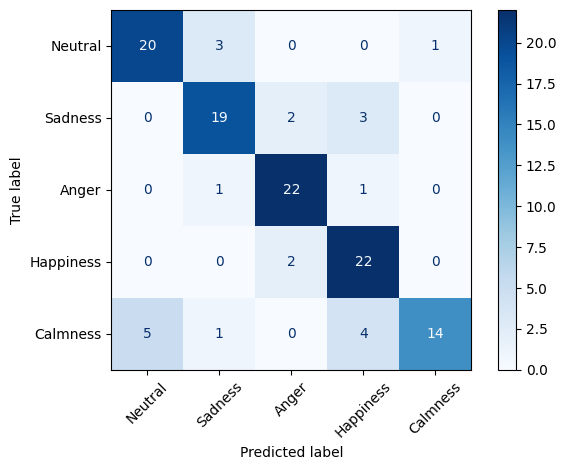

In [134]:
# Evaluate on test set
eeg_backbone.eval()
aud_backbone.eval()
for net in cogcn_nets:
    net.eval()

with torch.no_grad():
    _, feat_eeg_t = eeg_backbone(X_eeg_all, return_features=True)
    _, feat_aud_t = aud_backbone(X_aud_all, return_features=True)
    out_sum = cogcn_nets[0](feat_eeg_t) + cogcn_nets[1](feat_aud_t)

y_true = y_all[test_idx].cpu().numpy()
y_pred = out_sum[test_idx].argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")
print(f"Test acc: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=emotions)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.tight_layout()
plt.show()
